# EDA on the BIH dataset

Reads `bih_hourly.csv`, the output of `build_dataset.ipynb`. Set `HOURLY_ID` in
the next cell to that file's Drive ID and this runs anywhere, without needing
the Excel sources.

Everything here is computed on the *corrected* data. The coverage numbers from
the old `rhz_data.csv` were not trustworthy, because the columns they described
were mislabelled.

In [6]:
HOURLY_ID = "1VoXy12U5S6_NlPZyKoO32N7wjcJNMRoV"
BIJELJINA_ID = "1P1upIJyo600J73tGV99yf9QYiwD23g3L"

# DRIVE_DATASET = "/content/drive/MyDrive/air_pollution_bih/dataset"
# LOCAL_DATASET = "/home/sehy/Downloads/air_pollution_bih/dataset"

import os, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

if HOURLY_ID.strip():
    DATASET = "dataset"
    os.makedirs(DATASET, exist_ok=True)
    HOURLY = os.path.join(DATASET, "bih_hourly.csv")
    if not (os.path.exists(HOURLY) and os.path.getsize(HOURLY) > 0):
        try:                                  # install gdown only if we must
            import gdown
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown
        gdown.download(id=HOURLY_ID, output=HOURLY, quiet=False)
        if not (os.path.exists(HOURLY) and os.path.getsize(HOURLY) > 0):
            raise RuntimeError("download failed - check HOURLY_ID and that the "
                               "file is shared as 'Anyone with the link'.")
elif os.path.exists(os.path.join("dataset", "bih_hourly.csv")):
    DATASET = "dataset"                      # build_dataset.ipynb ran here
    HOURLY = os.path.join(DATASET, "bih_hourly.csv")
elif os.path.isdir(LOCAL_DATASET):
    DATASET = LOCAL_DATASET
    HOURLY = os.path.join(DATASET, "bih_hourly.csv")
else:
    from google.colab import drive
    drive.mount("/content/drive")
    DATASET = DRIVE_DATASET
    HOURLY = os.path.join(DATASET, "bih_hourly.csv")

bih = pd.read_csv(HOURLY, low_memory=False)
bih["datetime"] = pd.to_datetime(bih["datetime"])
POLLUTANTS = ["pm10", "pm25", "so2", "no2", "o3", "co"]

# One-hue sequential ramp for magnitude; text stays in ink, never a series colour.
BLUE = LinearSegmentedColormap.from_list("blue", ["#f2f6fb", "#cde2fb", "#86b6ef",
                                                  "#3987e5", "#1c5cab"])
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 120, "axes.edgecolor": "#d8d8d4",
                     "axes.labelcolor": MUTED, "text.color": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.spines.top": False, "axes.spines.right": False})

print(bih.shape, "|", bih.datetime.min(), "->", bih.datetime.max())
bih.head()

Downloading...
From: https://drive.google.com/uc?id=1VoXy12U5S6_NlPZyKoO32N7wjcJNMRoV
To: /content/dataset/bih_hourly.csv
100%|██████████| 102M/102M [00:00<00:00, 121MB/s] 


(815136, 20) | 2021-01-01 00:00:00 -> 2025-12-31 23:00:00


,source,city,station,datetime,year,month,day,hour,season,pm10,pm25,so2,no2,o3,co,temperature,humidity,wind_speed,wind_dir,pressure
0,rhz,Banja Luka,Banja Luka,2021-01-01 01:00:00,2021,1,1,1,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rhz,Banja Luka,Banja Luka,2021-01-01 02:00:00,2021,1,1,2,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rhz,Banja Luka,Banja Luka,2021-01-01 03:00:00,2021,1,1,3,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,rhz,Banja Luka,Banja Luka,2021-01-01 04:00:00,2021,1,1,4,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,rhz,Banja Luka,Banja Luka,2021-01-01 05:00:00,2021,1,1,5,winter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Coverage by city and pollutant

coverage % (share of hours with a real measurement)
            pm10  pm25   so2   no2    o3    co
city                                          
Banja Luka  84.5  83.4  84.7  87.0  86.9  86.0
Bihac       76.8  76.7  77.0  67.9  84.0  82.4
Brod        97.0  95.1  96.2  99.0  96.9  98.3
Doboj       70.3   0.0  73.4  61.7  68.5  21.0
Gacko       81.4   0.0  94.3  79.7   0.0   0.0
Livno       76.3  76.2  70.5  84.0  83.4  84.5
Mostar      52.8  52.8  56.3  51.6  41.2  58.0
Prijedor    49.4  47.7  71.6  65.6  51.0  63.8
Sarajevo    75.9  36.7  74.3  79.1  37.1  28.3
Trebinje    71.6  69.0  75.5  82.7  75.1  87.3
Tuzla       10.7  52.4  74.7  76.4  47.1  57.7
Ugljevik    47.2   0.0  65.9  96.7   0.0   0.0


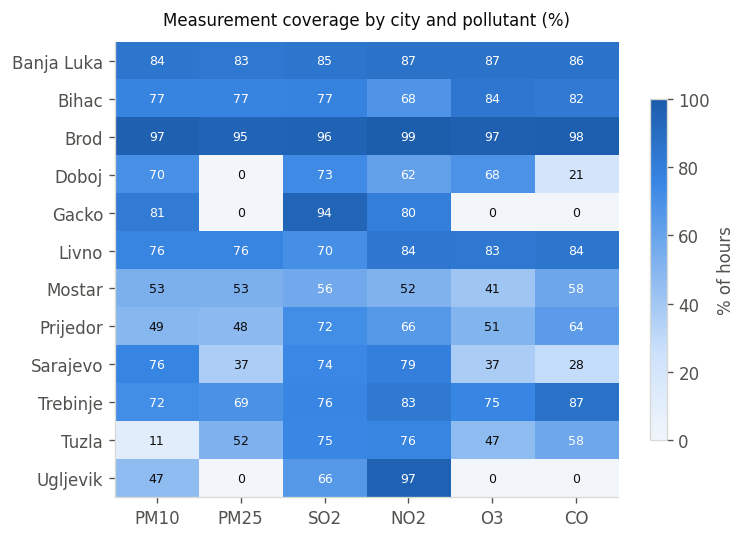

In [7]:
cov = bih.groupby("city")[POLLUTANTS].apply(lambda x: (1 - x.isna().mean()) * 100).round(1)
print("coverage % (share of hours with a real measurement)")
print(cov.to_string())

fig, ax = plt.subplots(figsize=(6.4, 4.6))
im = ax.imshow(cov.values, cmap=BLUE, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(POLLUTANTS)), [p.upper() for p in POLLUTANTS])
ax.set_yticks(range(len(cov.index)), cov.index)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                color="#ffffff" if v > 55 else INK)
ax.set_title("Measurement coverage by city and pollutant (%)", pad=10, fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.75, label="% of hours")
plt.tight_layout(); plt.show()

## Multi-station cities

A zero below is not a gap to impute - it is an instrument the station does not
have. That distinction matters when deciding what to drop.

In [8]:
# Sarajevo and Tuzla are the only multi-station cities; everywhere else is one
# station per city. Coverage varies a lot BETWEEN stations in the same city.
multi = bih[bih.city.isin(["Sarajevo", "Tuzla"])]
st = multi.groupby("station")[POLLUTANTS].apply(lambda x: (1 - x.isna().mean()) * 100).round(1)
print(st.to_string())
print()
print("Zeros here are instruments the station simply does not have:")
print(" - Ambasada measures ONLY pm25")
print(" - no Tuzla station except Trnovac measures pm10 at all")

               pm10  pm25   so2   no2    o3    co
station                                          
Ambasada        0.0  98.9   0.0   0.0   0.0   0.0
Bjelave        94.7  71.4  74.1  89.3  85.3  72.2
Hadzici        24.7   0.0  52.1  60.8  57.8  60.5
Ilidza         98.5  98.5  91.5  97.0   0.0  17.8
Ilijas         92.3   0.0  91.1  93.3   0.0   0.0
Isedlo         77.4   0.0  83.9  65.1  69.0   0.0
Otoka          93.3  24.7  94.6  94.7  94.3   0.0
Tuzla-BKC       0.0  94.8  92.2  97.1  31.3  58.5
Tuzla-Bukinje   0.0  17.6  95.5  94.1  68.6  87.2
Tuzla-Skver     0.0  84.1  92.5  95.2  76.6  70.7
Tuzla-Trnovac  53.6   0.0   0.0   0.0   0.0   0.0
Vijecnica      86.6   0.0  69.5  94.7   0.0  82.7
Vogosca        77.7  77.7  74.5  76.9   0.0   0.0

Zeros here are instruments the station simply does not have:
 - Ambasada measures ONLY pm25
 - no Tuzla station except Trnovac measures pm10 at all


## Coverage over time

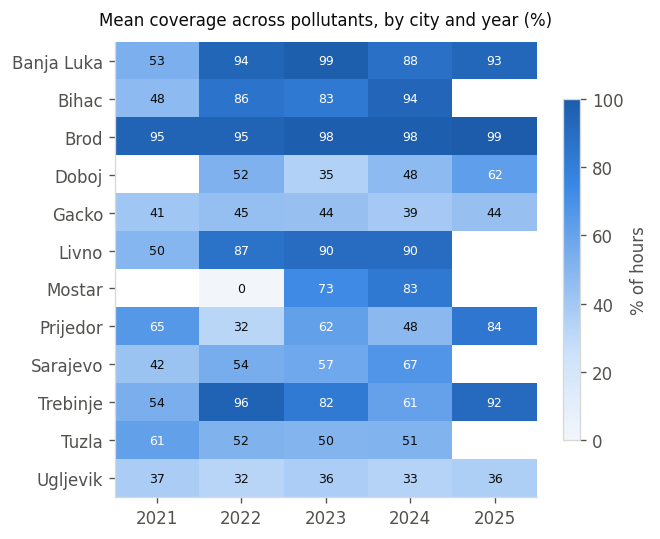

blank = city had no data at all that year


In [9]:
piv = (bih.groupby(["city", "year"])[POLLUTANTS]
          .apply(lambda x: (1 - x.isna().mean()).mean() * 100).unstack().round(1))
fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(piv.values, cmap=BLUE, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(piv.columns)), piv.columns)
ax.set_yticks(range(len(piv.index)), piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5,
                    color="#ffffff" if v > 55 else INK)
ax.set_title("Mean coverage across pollutants, by city and year (%)", pad=10, fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.75, label="% of hours")
plt.tight_layout(); plt.show()
print("blank = city had no data at all that year")

## PM2.5 from PM10

The ratio is strong and seasonal - winter is much higher, which is the coal and
wood domestic-heating signature under winter inversion.

Two cautions on using it to fill in PM2.5:

**Never use ratio-estimated PM2.5 in a test set.** You would be measuring how
well the model reproduces the ratio formula, not how well it predicts real
PM2.5 - a model that learned only `pm25 = 0.75 * pm10` would score almost
perfectly and mean nothing.

**Prefer feeding PM10 in as a feature** over synthesising a PM2.5 target. The
relationship is nonlinear and depends on season, humidity and inversion, and the
spread below (std ~0.16-0.20 even within a season) is what a fixed ratio throws
away. The ratio's honest uses are as EDA evidence about pollution sources, and
as a naive baseline the model has to beat.

267,288 hours with both PM2.5 and PM10 measured

        median    std  count
season                      
autumn   0.768  0.174  67027
spring   0.725  0.198  65578
summer   0.653  0.164  72493
winter   0.896  0.159  62190


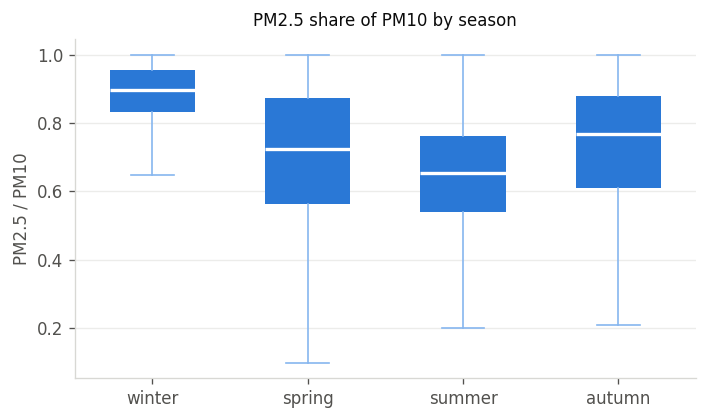

In [10]:
# PM2.5 / PM10 ratio, from the hours where BOTH were really measured.
d = bih[(bih.pm10 > 5) & (bih.pm25 > 0) & (bih.pm25 <= bih.pm10)].copy()
d["ratio"] = d.pm25 / d.pm10
print(f"{len(d):,} hours with both PM2.5 and PM10 measured\n")
print(d.groupby("season").ratio.agg(["median", "std", "count"]).round(3).to_string())

order = ["winter", "spring", "summer", "autumn"]
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.boxplot([d[d.season == s].ratio for s in order],
           showfliers=False, widths=0.55, patch_artist=True,
           medianprops=dict(color="#ffffff", linewidth=2),
           boxprops=dict(facecolor="#2a78d6", edgecolor="none"),
           whiskerprops=dict(color="#86b6ef"), capprops=dict(color="#86b6ef"))
ax.set_xticks(range(1, len(order) + 1), order)   # matplotlib renamed boxplot's
                                                 # `labels` arg in 3.9
ax.set_ylabel("PM2.5 / PM10")
ax.set_title("PM2.5 share of PM10 by season", fontsize=10, pad=8)
ax.grid(axis="y", color="#ececea", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [11]:
print(d.groupby("city").ratio.agg(["median", "std", "count"]).round(3).to_string())

            median    std  count
city                            
Banja Luka   0.732  0.197  35156
Bihac        0.773  0.189  24577
Brod         0.880  0.212  41185
Livno        0.687  0.167  23012
Mostar       0.698  0.165  12732
Prijedor     0.752  0.233  20211
Sarajevo     0.757  0.172  85636
Trebinje     0.651  0.157  24779


## Cleaned export

Cutoff is 2021-2024, the window where both networks have full years (FHZ stops
after 2024). Short gaps are interpolated and flagged; long gaps stay `NaN` so
the model can mask them.

In [12]:
CUTOFF = (2021, 2024)   # FHZ stops after 2024; RHZ runs to 2025

clean = bih[bih.year.between(*CUTOFF)].copy()

# Drop the (city, pollutant) pairs where the instrument does not exist at all,
# rather than leaving a column of NaN that looks imputable.
never = {}
for city, grp in clean.groupby("city"):
    missing = [p for p in POLLUTANTS if grp[p].isna().all()]
    if missing:
        never[city] = missing
        clean.loc[clean.city == city, missing] = np.nan
print("pollutants never measured at all (no instrument):")
for k, v in never.items():
    print(f"  {k:12s} {v}")

# Interpolate only short gaps (<= 3 h) within a station, and flag every value we
# touched so the model can tell real from filled.
clean = clean.sort_values(["station", "datetime"])
for c in POLLUTANTS + ["temperature", "wind_speed", "humidity", "pressure"]:
    clean[f"{c}_filled"] = clean[c].isna()
    clean[c] = clean.groupby("station")[c].transform(
        lambda s: s.interpolate(method="linear", limit=3, limit_area="inside"))
    clean[f"{c}_filled"] &= clean[c].notna()

# Wind direction is circular, so decompose it into components the model can use.
rad = np.deg2rad(clean.wind_dir)
clean["wind_u"] = -clean.wind_speed * np.sin(rad)
clean["wind_v"] = -clean.wind_speed * np.cos(rad)

out_path = os.path.join(DATASET, "bih_hourly_clean.csv")
clean.to_csv(out_path, index=False)
print(f"\nwrote {out_path}  {clean.shape}")
if not os.path.isabs(out_path):
    print("NOTE: this is Colab's temporary disk and is lost when the runtime "
          "restarts.\n      Mount Drive and copy it across if you want to keep it.")
print("\ncoverage after short-gap filling (%):")
print(((1 - clean[POLLUTANTS].isna().mean()) * 100).round(1).to_string())

pollutants never measured at all (no instrument):
  Doboj        ['pm25']
  Gacko        ['pm25', 'o3', 'co']
  Ugljevik     ['pm25', 'o3', 'co']

wrote dataset/bih_hourly_clean.csv  (753823, 32)
NOTE: this is Colab's temporary disk and is lost when the runtime restarts.
      Mount Drive and copy it across if you want to keep it.

coverage after short-gap filling (%):
pm10    62.9
pm25    46.2
so2     76.0
no2     79.2
o3      48.6
co      47.4


## Bijeljina (daily)

In [13]:
print("Bijeljina is DAILY, so it is kept in its own table rather than being")
print("resampled up to fake hourly rows.\n")

bij_path = os.path.join(DATASET, "bih_daily_bijeljina.csv")

if not os.path.exists(bij_path) and BIJELJINA_ID.strip():
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    os.makedirs(DATASET, exist_ok=True)
    gdown.download(id=BIJELJINA_ID, output=bij_path, quiet=False)

if os.path.exists(bij_path) and os.path.getsize(bij_path) > 0:
    bij = pd.read_csv(bij_path)
    print(bij.shape, list(bij.columns))
    display(bij.head())
else:
    print("bih_daily_bijeljina.csv not available - set BIJELJINA_ID, or run "
          "build_dataset.ipynb to create it.")

Bijeljina is DAILY, so it is kept in its own table rather than being
resampled up to fake hourly rows.



Downloading...
From: https://drive.google.com/uc?id=1P1upIJyo600J73tGV99yf9QYiwD23g3L
To: /content/dataset/bih_daily_bijeljina.csv
100%|██████████| 156k/156k [00:00<00:00, 64.0MB/s]

(1708, 16) ['date', 'so2', 'co', 'no2', 'no', 'nox', 'o3', 'pm25', 'pm10', 'co2', 'wind_speed', 'pressure', 'temperature', 'city', 'station', 'source']


,date,so2,co,no2,no,nox,o3,pm25,pm10,co2,wind_speed,pressure,temperature,city,station,source
0,2021-01-01,30.09,1.24,19.14,21.62,40.77,36.35,21.03,23.35,549.93,1.47,979.87,-1.44,Bijeljina,Bijeljina,rhz
1,2021-01-02,24.93,0.83,23.10,27.60,50.70,51.64,8.38,9.32,556.75,3.62,987.63,-0.20,Bijeljina,Bijeljina,rhz
2,2021-01-03,30.62,1.13,23.01,23.44,46.45,42.70,13.34,17.82,544.57,2.31,979.08,1.91,Bijeljina,Bijeljina,rhz
3,2021-01-04,29.41,1.11,26.45,24.53,50.98,46.00,35.55,39.77,547.32,1.84,967.35,0.20,Bijeljina,Bijeljina,rhz
4,2021-01-05,26.51,0.97,23.98,24.84,48.83,46.07,39.53,44.91,545.37,1.42,987.43,-0.82,Bijeljina,Bijeljina,rhz


In [14]:
RAW_IDS = {
    "fhz_data/pollutants/pollutants_1h/2021 1h.xls":  "1LAQBISLLPswqwhG-7lfXWBwxA4aiKJcF",
    "fhz_data/pollutants/pollutants_1h/2022 1h.xls":  "1r1UCDQsDql6AAXE2qpfmuwsSz-VnaOv2",
    "fhz_data/pollutants/pollutants_1h/2023 1h.xlsx": "1Of0JZgcr2GFiaO7ZeGXGg51QXTIMJ-sB",
    "fhz_data/pollutants/pollutants_1h/2024 1h.xlsx": "1MbKx4k_J00zawz_CY8yfBUSVH8K0AEgE",
    "fhz_data/pollutants/pollutants_1h/2025 1h.xlsx": "1dahe_DZMBb6C6jpuVpZ01DEvEB-UiXTn",
}

import re, glob, warnings
warnings.filterwarnings("ignore")

for rel, fid in RAW_IDS.items():
    out = os.path.join(DATASET, rel)
    if fid.strip() and not os.path.exists(out):
        try:
            import gdown
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown
        os.makedirs(os.path.dirname(out), exist_ok=True)
        gdown.download(id=fid, output=out, quiet=False)

POLLS = {"pm10", "pm25", "so2", "no2", "o3", "co"}

def _pol(s):
    k = re.sub(r"[^a-z0-9]", "", str(s).lower())
    k = re.sub(r"1?h$", "", k)
    return k if k in POLLS else None

def _st(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

def _ts(col):
    s = col.astype(str).str.strip()
    if s.str.fullmatch(r"\d{14}").mean() > 0.8:        # 20230101000000
        return pd.to_datetime(s, format="%Y%m%d%H%M%S", errors="coerce")
    return pd.to_datetime(col, format="mixed", errors="coerce")

files = sorted(glob.glob(os.path.join(DATASET, "fhz_data/pollutants/pollutants_1h/*.xls*")))
if not files:
    print("raw per-station exports not available - skipping this check.")
    print("Fill in RAW_IDS above to run it. It was run once and passed:")
    print("all year-by-pollutant correlations were exactly 1.0.")
else:
    rows = []
    for fp in files:
        book = pd.ExcelFile(fp)
        for sh in book.sheet_names:
            pol = _pol(sh)
            if not pol:
                continue
            raw = book.parse(sh, header=None)
            hrow = tcol = None
            for r in range(min(3, len(raw))):
                keys = [re.sub(r"[^a-z]", "", str(v).lower()) for v in raw.iloc[r]]
                if "endtime" in keys:
                    hrow, tcol = r, keys.index("endtime")
                    break
            if hrow is None:
                hrow, tcol = 0, 0
            names = {}
            for i in range(tcol + 1, raw.shape[1]):
                for r in range(hrow + 1):
                    v = raw.iat[r, i]
                    if isinstance(v, str) and v.strip() and _pol(v) is None:
                        names[i] = v.strip()
                        break
            first = hrow + 1
            if not pd.to_numeric(raw.iloc[first, list(names)], errors="coerce").notna().any():
                first += 1
            body = raw.iloc[first:]
            ts = _ts(body[tcol])
            for i, name in names.items():
                rows.append(pd.DataFrame({
                    "datetime": ts.values, "st": _st(name), "pol": pol,
                    "want": pd.to_numeric(body[i], errors="coerce").values}))

    rl = pd.concat(rows, ignore_index=True).dropna(subset=["datetime", "want"])
    rl["datetime"] = rl.datetime.dt.round("h")
    rl = rl.groupby(["datetime", "st", "pol"], as_index=False).want.mean()

    fh = bih[bih.source == "fhz"].copy()
    fh["st"] = fh.station.map(_st)
    got = fh.melt(id_vars=["datetime", "st"], value_vars=sorted(POLLS),
                  var_name="pol", value_name="got").dropna(subset=["got"])

    m = rl.merge(got, on=["datetime", "st", "pol"], how="inner")
    m["yr"] = m.datetime.dt.year
    print("correlation by year x pollutant (1.0 = exact match):")
    print(m.groupby(["yr", "pol"])
           .apply(lambda g: round(g.want.corr(g.got), 5)).unstack().to_string())
    d = (m.want - m.got).abs()
    print(f"\ncompared {len(m):,} values | differing by >1%: "
          f"{(d > 0.01 * m.want.abs().clip(lower=1)).sum()}")

Downloading...
From: https://drive.google.com/uc?id=1LAQBISLLPswqwhG-7lfXWBwxA4aiKJcF
To: /content/dataset/fhz_data/pollutants/pollutants_1h/2021 1h.xls
100%|██████████| 15.7M/15.7M [00:00<00:00, 153MB/s]
Downloading...
From: https://drive.google.com/uc?id=1r1UCDQsDql6AAXE2qpfmuwsSz-VnaOv2
To: /content/dataset/fhz_data/pollutants/pollutants_1h/2022 1h.xls
100%|██████████| 18.8M/18.8M [00:00<00:00, 171MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Of0JZgcr2GFiaO7ZeGXGg51QXTIMJ-sB
To: /content/dataset/fhz_data/pollutants/pollutants_1h/2023 1h.xlsx
100%|██████████| 10.4M/10.4M [00:00<00:00, 217MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MbKx4k_J00zawz_CY8yfBUSVH8K0AEgE
To: /content/dataset/fhz_data/pollutants/pollutants_1h/2024 1h.xlsx
100%|██████████| 13.7M/13.7M [00:00<00:00, 161MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dahe_DZMBb6C6jpuVpZ01DEvEB-UiXTn
To: /content/dataset/fhz_data/pollutants/pollutants_1h/2025 1h.xlsx
100%|██████████| 12.6M/1

correlation by year x pollutant (1.0 = exact match):
pol    co  no2   o3  pm10  pm25  so2
yr                                  
2021  1.0  1.0  1.0   1.0   1.0  1.0
2022  1.0  1.0  1.0   1.0   1.0  1.0
2023  1.0  1.0  1.0   1.0   1.0  1.0
2024  1.0  1.0  1.0   1.0   1.0  1.0

compared 1,639,722 values | differing by >1%: 1
